## HateXplain - 4 OBJECTIVES

### Multi Task Learning

* **Dataset:** HateXplain
* **Task :** Classification
* **Target 1:** Hate speech
* **Target 2:** Hate speech against woman
* **Target 3:** Hate speech against homosexual
* **Target 4:** Hate speech against indigenous

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import random
import torch
import numpy as np
from datasets import load_dataset

/home/lineccsa/mestrado/machinemoo/venv_moo/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
from machinemoo import moo
from machinemoo import get_objectives, get_models
from machinemoo.analysis.visualization import plot_pareto, plot_multiple_hypervolumes
from machinemoo.analysis.metrics import compute_hypervolume_progress

import preprocessing as pp
from scalarization import NLPScalarization

Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10


In [4]:
# Setting a seed for reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

set_seed()

## Dataset and Model

In [5]:
# Carregar o dataset HateXplain
dataset = load_dataset("Hate-speech-CNERG/hatexplain", trust_remote_code=True)

# model_name = "tum-nlp/bert-hateXplain"
#"hate-bert, uncased bert"
model_name="bert-base-uncased"

In [6]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda:0


In [7]:
task_config = {
    "General": {"type": "hate_speech"},
    "Women": {"type": "group_hate", "group": "Women"},
    "Homosexual": {"type": "group_hate", "group": "Homosexual"},
    "Indigenous": {"type": "group_hate", "group": "Indigenous"},
    "African": {"type": "group_hate", "group": "African"}
}

train_dataloader = pp.get_dataloader(dataset['train'], task_config)

100%|██████████| 481/481 [02:03<00:00,  3.89it/s]


## MOO Modeling and Training

* MOO methods:
    * MOLA
    * Random Weights

In [8]:
# Setting optimization parameter to use in all methods in this experiment
opt_params = {
    'node_time_limit': 2,
    'target_size': 150,
    'target_gap': 0,
    'node_gap': 0.05,
    'norm': False
}
results = {}
task_names = list(task_config.keys())

### MOLA

18:15:21 | DEBUG | machinemoo | Filtered parameters for Mola: {'node_time_limit': 2, 'target_size': 150, 'target_gap': 0, 'node_gap': 0.05, 'norm': False}
18:15:21 | DEBUG | machinemoo | Finding 1th individual minimum
Epoch 1/3: 100%|██████████| 241/241 [00:06<00:00, 37.24it/s]


Epoch 1 - Average loss: 0.7344


Epoch 2/3: 100%|██████████| 241/241 [00:05<00:00, 45.91it/s]


Epoch 2 - Average loss: 0.7190


Epoch 3/3: 100%|██████████| 241/241 [00:05<00:00, 40.48it/s]


...

Epoch 3/3: 100%|██████████| 241/241 [00:03<00:00, 76.57it/s]


Epoch 3 - Average loss: 0.5721


19:07:56 | DEBUG | machinemoo | New solution dominated [0.58940778 0.3514326  0.26591685 0.02153314 0.35312195]


load_solution=False and check results.termination_condition and
results.found_feasible_solution() before loading a solution.


19:07:58 | DEBUG | machinemoo | Calculated weights: [0.88146582 0.         0.11853418 0.         0.        ]
19:07:58 | DEBUG | machinemoo | Importance: 1.7630408158830768e-05
19:07:58 | DEBUG | machinemoo | Global lower bound (y*): [0.58882402 0.35026395 0.26543993 0.02134235 0.35243352]
19:07:58 | DEBUG | machinemoo | Iteration 150
19:07:58 | DEBUG | machinemoo | Solutions list: [array([0.58950891, 0.35026395, 0.26594012, 0.02153008, 0.35243352]), array([0.58983504, 0.35081362, 0.26552024, 0.02152875, 0.35250063]), array([0.58952198, 0.35051714, 0.26543993, 0.02152616, 0.35255946]), array([0.58982678, 0.3507699 , 0.26576134, 0.02152178, 0.35297985]), array([0.58966258, 0.35059309, 0.26556535, 0.02151549, 0.35308373]), array([0.58946571, 0.35043652, 0.26589427, 0.02151821, 0.35318977]), array([0.58924378, 0.35058455, 0.26663964, 0.02150038, 0.35310219]), array([0.58916435, 0.35031689, 0.26600578, 0.02150292, 0.35254467]), array([0.5895692 , 0.35035904, 0.2660261 , 0.02148978, 0.352657

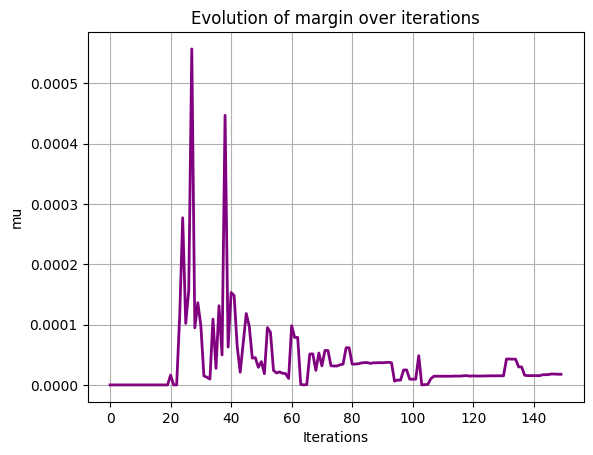

19:07:58 | INFO | machinemoo | Fit runtime: 3156.39 seconds


In [9]:
method = 'mola'
w_scalar = NLPScalarization(train_dataloader = train_dataloader, 
                            device = device, 
                            task_names = task_names, 
                            gradient = False)
moopt = moo(w_scalar).mo_optimization(method, **opt_params)
objs = get_objectives(moopt)
hypervolume_values = moopt.get_hypervolumes()
results[method] = {
                "moopt": moopt,
                "objectives": objs,
                "models": get_models(moopt),
                "hypervolume": hypervolume_values
            }

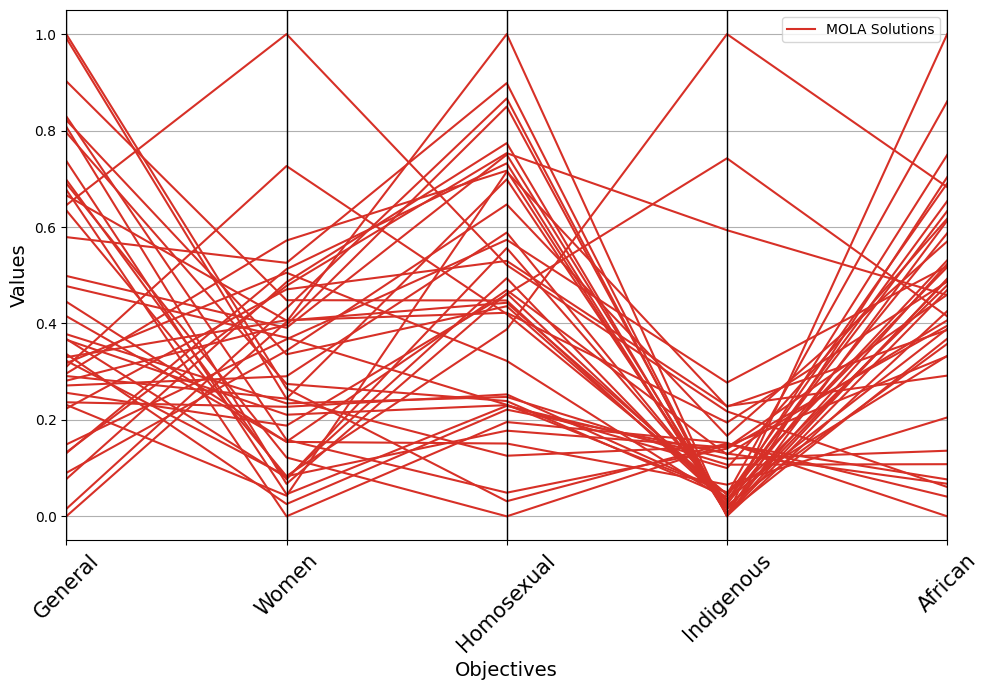

In [10]:
title="Loss Trade-offs in Multi-Group Hate Speech Detection"
plot_pareto(methods={'mola': results['mola']['objectives']},
            labels=task_names, 
            title=title,
            fontsize=15,
            figsize=(10,7),
            save_path='images/4_objs_mola.pdf'
            )

19:07:58 | DEBUG | machinemoo | Filtered parameters for Mola: {'node_time_limit': 2, 'target_size': 150, 'target_gap': 0, 'node_gap': 0.05, 'norm': False}
19:07:58 | DEBUG | machinemoo | Finding 1th individual minimum
Epoch 1/3: 100%|██████████| 241/241 [00:02<00:00, 90.76it/s]


Epoch 1 - Average loss: 0.7082


Epoch 2/3: 100%|██████████| 241/241 [00:02<00:00, 91.81it/s]


Epoch 2 - Average loss: 0.6961


Epoch 3/3: 100%|██████████| 241/241 [00:02<00:00, 87.23it/s]


...

Epoch 2/3: 100%|██████████| 241/241 [00:05<00:00, 41.49it/s]


Epoch 2 - Average loss: 0.6116


Epoch 3/3: 100%|██████████| 241/241 [00:05<00:00, 41.52it/s]


Epoch 3 - Average loss: 0.6110


19:40:05 | DEBUG | machinemoo | New solution dominated [0.58957248 0.37991526 0.29346059 0.07278645 0.39268633]
19:40:05 | INFO | machinemoo | [Lipschitz] Updated global lower bounds: [0.09626535 0.21006782 0.17029687 0.01101533 0.08780884]
19:40:05 | DEBUG | machinemoo | Calculated weights: [1. 0. 0. 0. 0.]
19:40:05 | DEBUG | machinemoo | Importance: 0.4925184990121628
19:40:05 | DEBUG | machinemoo | Global lower bound (y*): [0.09626535 0.21006782 0.17029687 0.01101533 0.08780884]
19:40:05 | DEBUG | machinemoo | Iteration 150
19:40:05 | DEBUG | machinemoo | Solutions list: [array([0.58895472, 0.37887699, 0.29279966, 0.07238048, 0.39243136]), array([0.58878385, 0.37936841, 0.29327831, 0.07186625, 0.39257685]), array([0.58912359, 0.37893339, 0.29285804, 0.07182181, 0.39232507]), array([0.58932113, 0.37890256, 0.29287099, 0.07176264, 0.39231388]), array([0.58915462, 0.37894472, 0.29263569, 0.07171814, 0.39243952]), array([0.58947275, 0.3790194 , 0.29268735, 0.07167433, 0.39201448]), arra

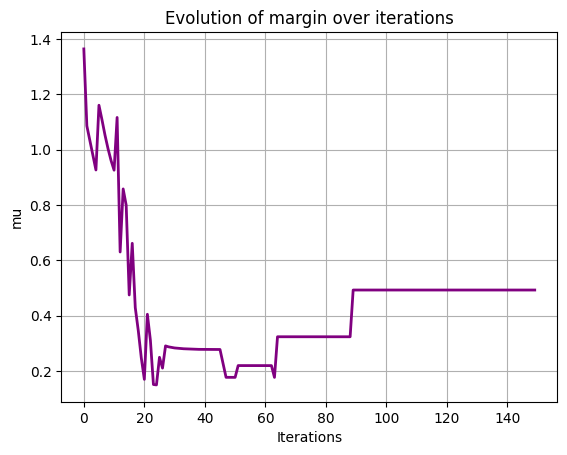

19:40:06 | INFO | machinemoo | Fit runtime: 1927.21 seconds


In [11]:
method = 'mola'
w_scalar = NLPScalarization(train_dataloader = train_dataloader, 
                            device = device, 
                            task_names = task_names, 
                            gradient = True)
moopt = moo(w_scalar).mo_optimization(method, **opt_params)
objs = get_objectives(moopt)
hypervolume_values = moopt.get_hypervolumes()
results[f'{method}_grad'] = {
                "moopt": moopt,
                "objectives": objs,
                "models": get_models(moopt),
                "hypervolume": hypervolume_values
            }

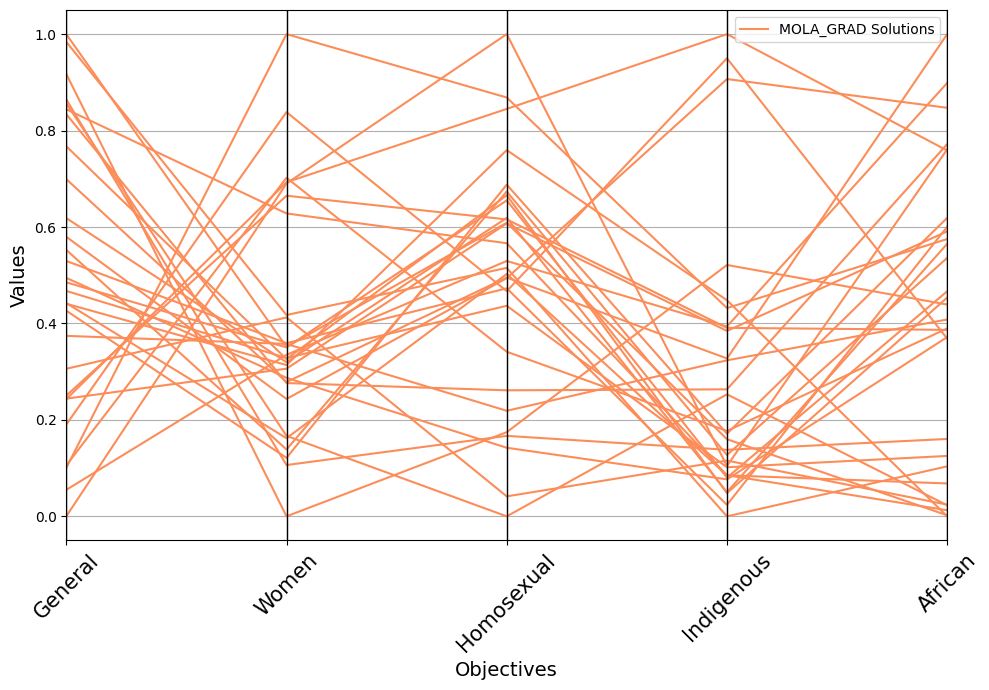

In [12]:
title="Loss Trade-offs in Multi-Group Hate Speech Detection"
plot_pareto(methods={'mola_grad': results['mola_grad']['objectives']},
            color=['#fc8d59'],
            labels=task_names, 
            title=title,
            fontsize=15,
            figsize=(10,7),
            save_path='images/4_objs_mola_grad.pdf'
            )

### Random Weight

In [13]:
method = 'random_weight'
w_scalar = NLPScalarization(train_dataloader = train_dataloader, 
                            device = device, 
                            task_names = task_names, 
                            gradient = True)
moopt = moo(w_scalar).mo_optimization(method, **opt_params)
objs = get_objectives(moopt)
hypervolume_values = compute_hypervolume_progress(objs)
results[f'{method}_grad'] = {
                "moopt": moopt,
                "objectives": objs,
                "models": get_models(moopt),
                "hypervolume": hypervolume_values
            }

19:40:06 | WARNING | machinemoo | Ignored parameters for random_weights: {'nodeGap', 'nodeTimeLimit', 'targetGap'}
19:40:06 | DEBUG | machinemoo | Filtered parameters for random_weights: {'targetSize': 150, 'norm': False}
19:40:06 | DEBUG | machinemoo | Finding 1th individual minima
Epoch 1/3: 100%|██████████| 241/241 [00:06<00:00, 37.72it/s]


Epoch 1 - Average loss: 0.7177


Epoch 2/3: 100%|██████████| 241/241 [00:05<00:00, 42.55it/s]


Epoch 2 - Average loss: 0.7048


Epoch 3/3: 100%|██████████| 241/241 [00:05<00:00, 41.94it/s]


...

Epoch 2/3: 100%|██████████| 241/241 [00:02<00:00, 83.75it/s]


Epoch 2 - Average loss: 0.2321


Epoch 3/3: 100%|██████████| 241/241 [00:03<00:00, 74.61it/s]


Epoch 3 - Average loss: 0.2329


20:13:18 | DEBUG | machinemoo | 150th solution


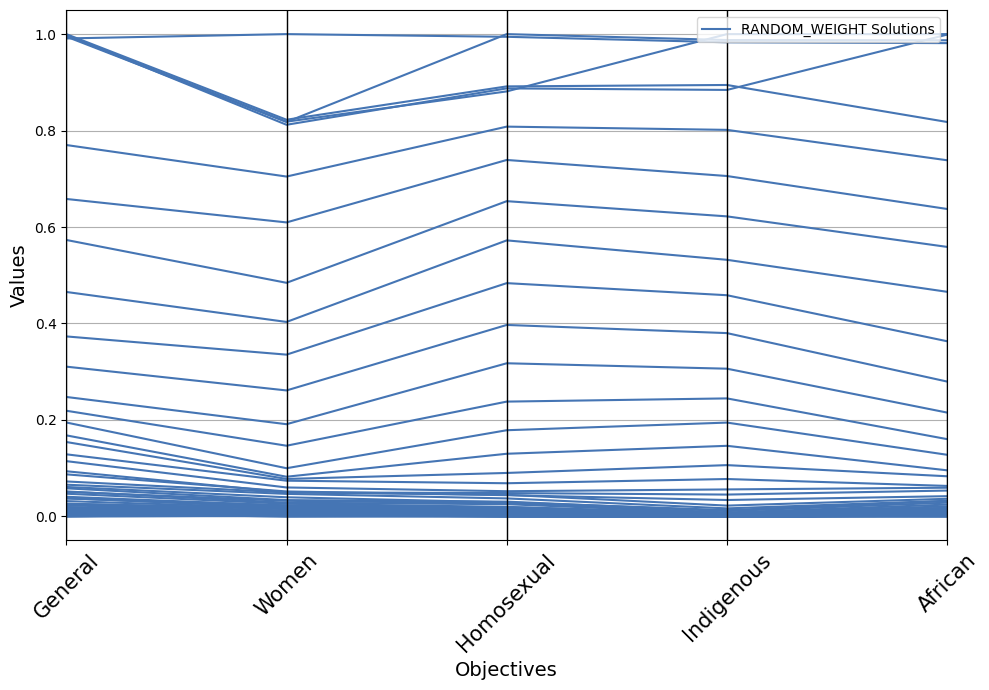

In [14]:
plot_pareto(methods={'random_weight': objs},
            labels=task_names, 
            title=title,
            fontsize=15,
            figsize=(10,7),
            color=['#4575b4'],
            save_path='images/4_objs_rw.pdf'
            )

In [15]:
import numpy as np
from pymoo.util.nds.non_dominated_sorting import NonDominatedSorting

# Supondo que `solutions` seja seu array (N x M)
solutions = objs

# Identifica os índices das soluções não-dominadas
nd_indices = NonDominatedSorting().do(solutions, only_non_dominated_front=True)

# Extrai as soluções não-dominadas
non_dominated_solutions = solutions[nd_indices]


print(f"mola: {len(results['mola']['objectives'])}")
print(f"mola_grad: {len(results['mola_grad']['objectives'])}")

print(f"Número de soluções não-dominadas (RW): {len(non_dominated_solutions)}")
print(non_dominated_solutions)

mola: 42
mola_grad: 29
Número de soluções não-dominadas (RW): 37
[[6.18397320e-03 5.18257663e-04 1.81352848e-03 8.64382990e-04
  1.97533615e-03]
 [6.22935661e-03 1.00155478e-03 5.12175996e-04 6.33324825e-04
  3.31050583e-04]
 [1.93441336e-03 2.76250285e-03 1.42141023e-03 1.52725701e-03
  0.00000000e+00]
 [5.93884226e-05 9.30048634e-04 6.86713524e-04 5.33330671e-04
  2.42028600e-04]
 [2.05171519e-03 9.47259012e-04 1.66751995e-03 5.31401499e-04
  1.46106270e-03]
 [4.17310448e-03 0.00000000e+00 6.13571658e-04 5.12960838e-04
  2.06377768e-03]
 [9.64781805e-04 2.95513460e-03 1.24822405e-03 4.54536260e-04
  2.08103823e-03]
 [2.91945118e-03 1.83331623e-03 6.96392088e-04 4.39270458e-04
  2.09381025e-03]
 [5.15352399e-04 2.45702137e-03 8.49790508e-04 4.56951516e-04
  2.07285069e-03]
 [2.01759402e-03 2.92351153e-03 7.98268808e-04 3.68434876e-04
  6.07246908e-04]
 [3.71714813e-03 7.43478423e-04 2.98705185e-04 1.16379075e-03
  1.22720525e-03]
 [3.51837971e-03 8.46225046e-04 8.44189830e-04 3.106780

## A posteriori Decision Making

* Comparison between MOO methods
* Ensemble and Evaluation

In [16]:
from machinemoo.analysis.visualization import plot_multiple_hypervolumes

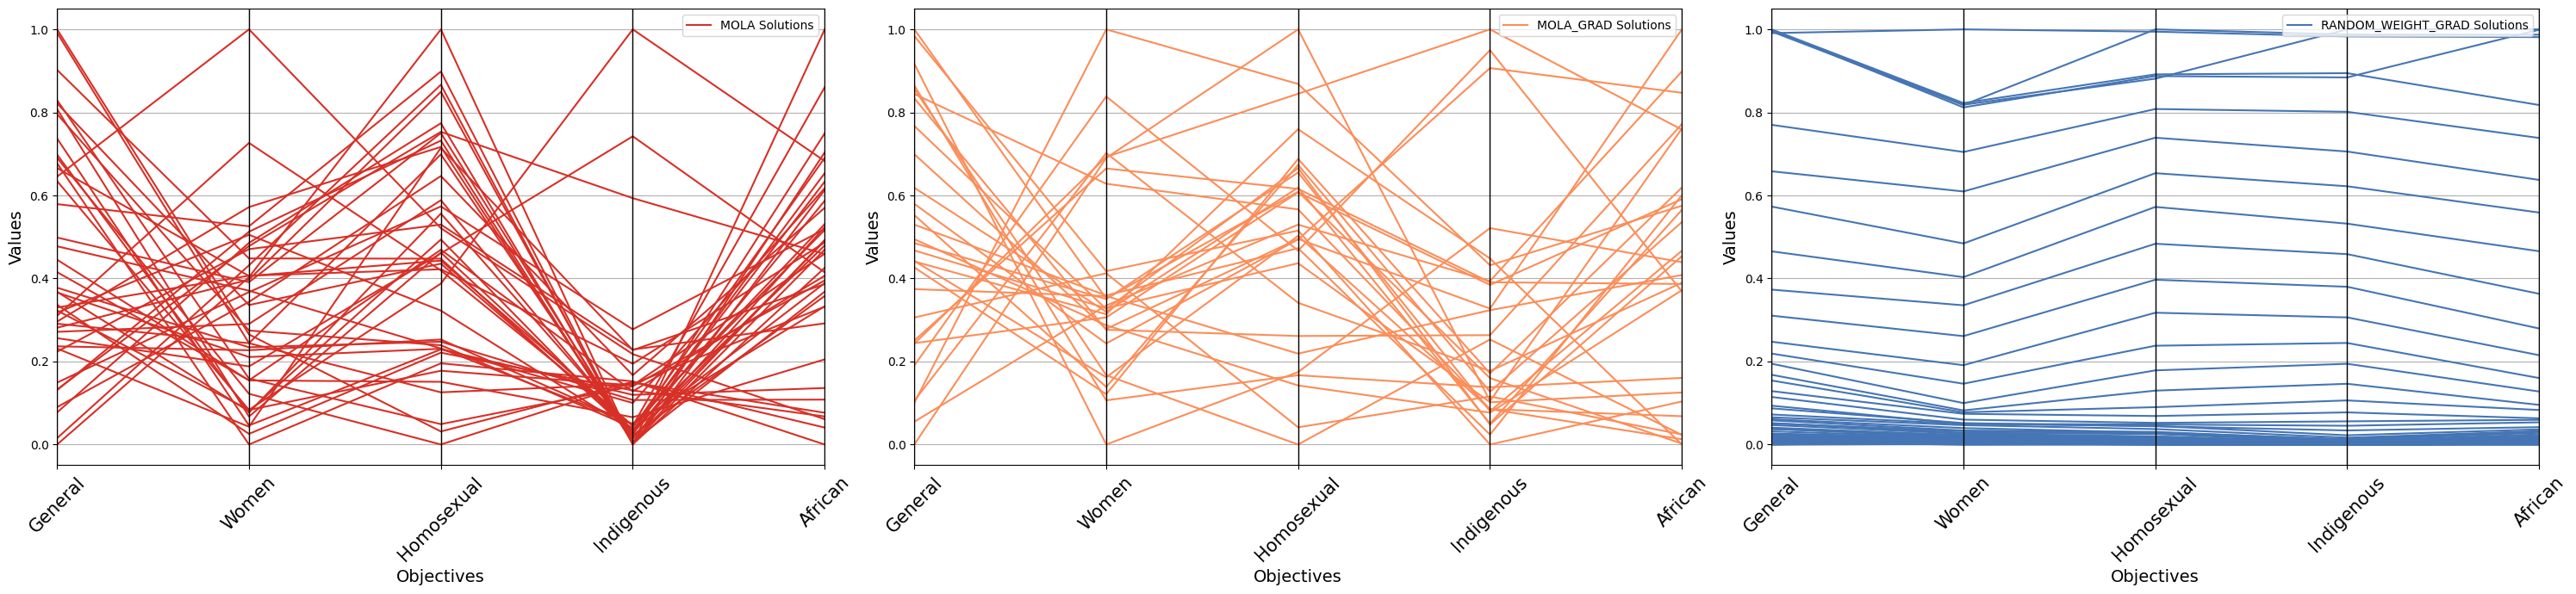

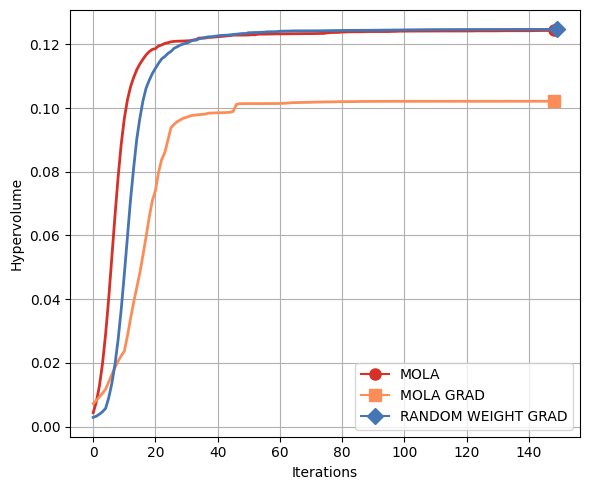

<Figure size 640x480 with 0 Axes>

In [17]:
pareto_dict = {
        method: res["objectives"]
        for method, res in results.items()
        if "objectives" in res
    }

hypervolumes_dict = {
        method: res["hypervolume"]
        for method, res in results.items()
        if "hypervolume" in res
    }

plot_pareto(methods=pareto_dict,
            labels=task_names, 
            title="",
            fontsize=15,
            figsize=(10,7),
            save_path='images/4_objs_methods.pdf'
            )
plot_multiple_hypervolumes(methods_hv=hypervolumes_dict, save_path="images/4_objs_hypervolume.pdf")

In [18]:
from machinemoo.analysis.decision import get_best_median_solution, get_best_weighted_solution

In [19]:
res_median = get_best_median_solution(results['mola']['objectives'], results['mola']['models'])

In [20]:
res_median

(array([0.33661672, 0.02553482, 0.22124256, 0.13021253, 0.06756161]),
 MultiTaskModel(
   (dropout): Dropout(p=0.3, inplace=False)
   (shared_fc): Linear(in_features=50, out_features=32, bias=True)
   (classifiers): ModuleDict(
     (General): Linear(in_features=32, out_features=2, bias=True)
     (Women): Linear(in_features=32, out_features=2, bias=True)
     (Homosexual): Linear(in_features=32, out_features=2, bias=True)
     (Indigenous): Linear(in_features=32, out_features=2, bias=True)
     (African): Linear(in_features=32, out_features=2, bias=True)
   )
 ),
 np.float64(0.13021252634064326),
 7)

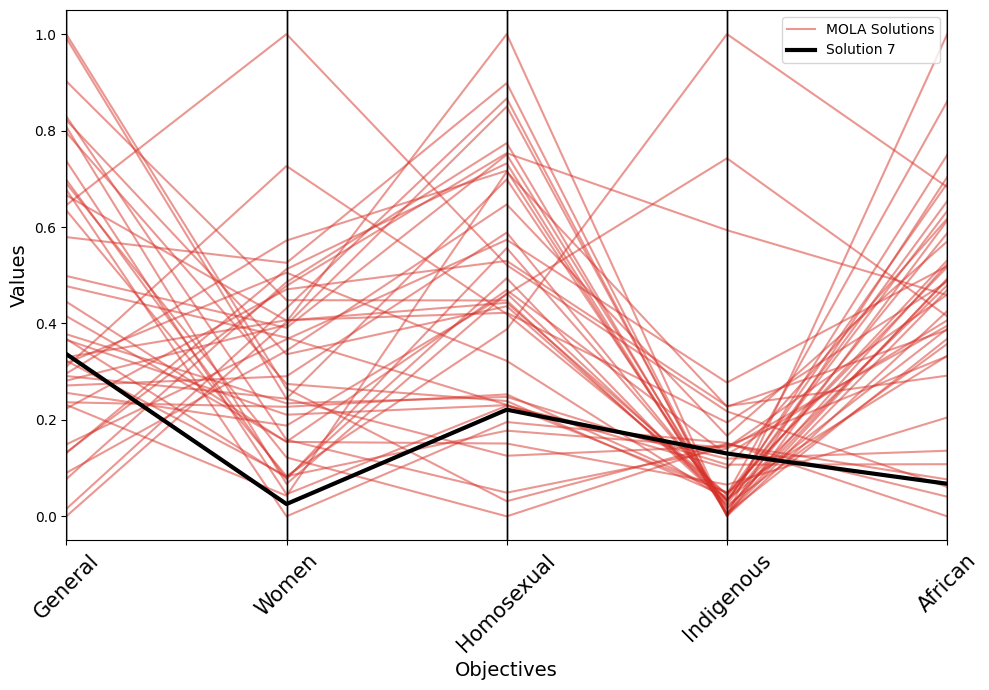

In [21]:
plot_pareto(methods={'mola': results['mola']['objectives']},
            labels=task_names, 
            title=title,
            fontsize=15,
            figsize=(10,7),
            point=res_median[0],
            point_label=f'Solution {res_median[3]}',
            save_path='images/4_objs_methods_median.pdf',
            alpha=0.5,
            s_factor=4
            )

In [22]:
res = get_best_weighted_solution(results['mola']['objectives'], results['mola']['models'], [0.2, 0.4, 0.2, 0.2])

ValueError: Weights vector must have the same length as each objective vector.

In [ ]:
res

(array([0.28144006, 0.33166822, 0.57432959, 0.12262121]),
 MultiTaskModel(
   (dropout): Dropout(p=0.3, inplace=False)
   (shared_fc): Linear(in_features=50, out_features=32, bias=True)
   (classifiers): ModuleDict(
     (General): Linear(in_features=32, out_features=2, bias=True)
     (Women): Linear(in_features=32, out_features=2, bias=True)
     (Homosexual): Linear(in_features=32, out_features=2, bias=True)
     (Indigenous): Linear(in_features=32, out_features=2, bias=True)
   )
 ),
 np.float64(0.3283454594049103),
 4)

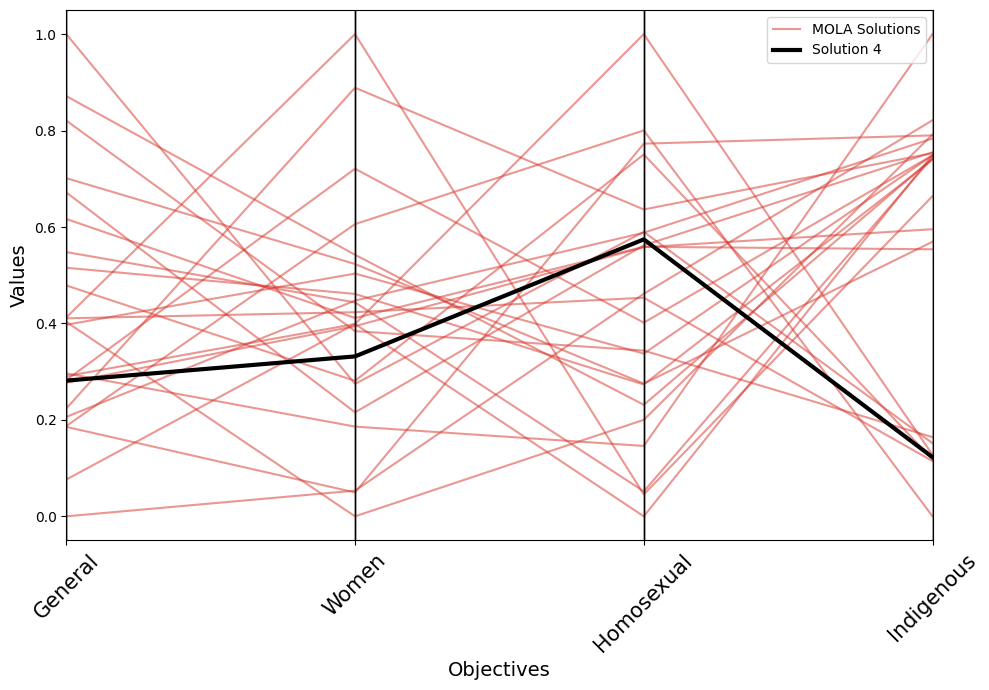

In [ ]:
plot_pareto(methods={'mola': results['mola']['objectives']},
            labels=task_names, 
            title=title,
            fontsize=15,
            figsize=(10,7),
            point=res[0],
            point_label=f'Solution {res[3]}',
            save_path='images/4_objs_methods_weighted.pdf',
            s_factor=4,
            alpha=0.5
            )

In [ ]:
import numpy as np
from pymoo.util.nds.non_dominated_sorting import NonDominatedSorting

# Supondo que `solutions` seja seu array (N x M)
solutions = results['random_weight']['objectives']

# Identifica os índices das soluções não-dominadas
nd_indices = NonDominatedSorting().do(solutions, only_non_dominated_front=True)

# Extrai as soluções não-dominadas
non_dominated_solutions = solutions[nd_indices]


print(f"mola: {len(results['mola']['objectives'])}")
print(f"mola_grad: {len(results['mola_grad']['objectives'])}")

print(f"Número de soluções não-dominadas (RW): {len(non_dominated_solutions)}")
print(non_dominated_solutions)

KeyError: 'random_weight'